Begin processing. Import required libraries.

In [407]:
# Import statements

import pandas as pd

# manage paths
from pathlib import Path
# plotting
from matplotlib import pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# dates
import datetime as dt
# numbers
import numpy as np
# Return errors iirc
from collections.abc import Callable
from contextlib import redirect_stdout
import traceback
# input output
import io
# sensitivity test
import itertools
# process images
from PIL import Image
# use this for netcdf file info.
import xarray as xr


from mrrpropy.raw_class import MRRProData
from mrrpropy.hexagram import plot_process_to_hexagram
from mrrpropy.plotting.processes import plot_fused_process_quicklook



Create useful defaults and accept inputs for layer, period, and a target time. _input, _debug, and _debug can be used for dev options. ARGS can be used to selectively render graphs (similar to running plots with arguments.)

In [408]:
# Setup/Init

# Paths
RAW_PATH = Path(r"C:\Projects\mrrpropy\tests\data\RAW\20241028_220000.nc")
OUTPUT_DIR = Path("C:/Projects/mrrpropy/tests/data/PRODUCTS/" + RAW_PATH.stem)
PRODUCT_PATH = Path(r"C:\Projects\mrrpropy\tests\data\PRODUCTS\20241028_220000_raprompro.nc")

# Change only to match a specific function (or set of functions!) if you only want to view one or more.
ARGS = {
    "output_dir": OUTPUT_DIR,
    "only": "plot-dsd-by-range",
}

_input = 1 # Control if you want to input the target time and layer range or just use defaults. 1 for input, 0 for defaults.
_bypass = 0
_debug = 0

# defaults 
PERIOD = (dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S"), dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S")+dt.timedelta(minutes=59))
TARGET_TIME = dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S") + dt.timedelta(minutes=30)
LAYER = (1000.0, 2000.0)  

# Define useful variables.
if _input == 1:
    try:
        PERIOD = tuple(dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S") + dt.timedelta(minutes=int(ts.strip())) for ts in input("Please input time range M, M ").split(","))
        TARGET_TIME = dt.datetime.strptime(RAW_PATH.stem, "%Y%m%d_%H%M%S") + dt.timedelta(minutes=int(input("Please input minute timestamp of target time. ")))
        LAYER = tuple(int(x) for x in input("Please input layer range in meters (e.g. [1000, 2000]): ").split(","))
    except:
        print(f"Error in input formatting. You entered (or left blank) {PERIOD}, {TARGET_TIME}, and {LAYER}, at least one of which was the wrong format.")
        
      
QUICKLOOK_PROCESSES = [
    "breakup",
    "growth_depletion",
    "growth_depletion_loss",
    "growth_depletion_gain",
    "activation",
    "evaporation",
    "growth",
]


Process raw file, or use the existing raw.

In [409]:
# Start by processing the RAW file.
# Load the raw file
mrr = MRRProData.from_file(RAW_PATH)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# build the product path using Path / (stem + suffix)
PRODUCT_PATH = OUTPUT_DIR / (RAW_PATH.stem + "_raprompro.nc")

if PRODUCT_PATH in OUTPUT_DIR.glob("*_raprompro.nc") and _debug == 0:
    print(f"Processed file already exists in {OUTPUT_DIR}. Skipping processing.")
    mrr.load_raprompro(PRODUCT_PATH)
else:
    # Process and save (pass OUTPUT_DIR as a Path)
    mrr.process_raprompro_optimized(save=True, output_dir=OUTPUT_DIR, save_dsd_3d=True, save_spe_3d=True)


Processed file already exists in C:\Projects\mrrpropy\tests\data\PRODUCTS\20241028_220000. Skipping processing.


Create useful class for the column scan process.

In [410]:
# Create the PlotContext class 

# This is useful--helps scan for context/classification. Might replace with gradient descent at some point.
class PlotContext:
    
    # Check that raw and processed files exist
    def __init__(self) -> None:
        if not RAW_PATH.exists():
            raise FileNotFoundError(f"Missing RAW fixture: {RAW_PATH}")
        if not PRODUCT_PATH.exists():
            raise FileNotFoundError(f"Missing RaProMPro product: {PRODUCT_PATH}")

        # Reload the MRRProData to ensure we have a clean state and the processed data is loaded.
        self.mrr = MRRProData.from_file(RAW_PATH)
        self.mrr.load_raprompro(PRODUCT_PATH)
        self._analysis_fixed = None
        self._classified_fixed = None
        self._scan_df = None

    # close mrr object
    def close(self) -> None:
        self.mrr.close()

    # Get target range from dataset.
    @property
    def target_range(self) -> float:
        ds = self.mrr.ds
        return float(ds["range"].values[ds.sizes["range"] // 2])

    # Process and analyze.
    @property
    def fixed_analysis(self):
        if self._analysis_fixed is None:
            self._analysis_fixed = self.mrr.rain_process_analyze(
                period=PERIOD,
                k=11,
                selection_mode="fixed_layer",
                z_bottom_m=LAYER[0],
                z_top_m=LAYER[1],
                ze_th=-5.0,
                min_points_trend=10,
                eps_q=0.01,
                rgb_q=0.02,
                vars_trend=("Dm", "Nw", "LWC"),
            )
        return self._analysis_fixed

    # Run classification on the fixed layer analysis.
    @property
    def fixed_classified(self):
        if self._classified_fixed is None:
            self._classified_fixed = self.mrr.classify_rain_process(
                analysis=self.fixed_analysis
            )
        return self._classified_fixed

    # Make a scanning dataframe.
    @property
    def scan_df(self) -> pd.DataFrame:
        if self._scan_df is None:
            self._scan_df = self.mrr.build_column_process_scan_dataframe(
                period=PERIOD,
                k=11,
                window_thickness_m=500.0,
                window_step_m=None,
                min_tau_strength=0.3,
            )
        return self._scan_df

    # Pick the first meaningful process label from the fixed layer classification.
    @property
    def representative_process(self) -> str:
        labels = self.fixed_classified["proc_label"].values.astype(str)
        process = next(
            (
                label
                for label in labels
                if label not in {"no_data", "unknown", "steady_or_weak"}
            ),
            None,
        )
        if process is not None:
            return str(process)
        fallback = next((label for label in labels if label != "no_data"), None)
        return str(fallback or "steady_or_weak")

    # Return up to two meaningful labels.
    @property
    def representative_processes(self) -> list[str]:
        labels = sorted(
            {
                label
                for label in self.fixed_classified["proc_label"].values.astype(str)
                if label not in {"no_data", "unknown", "steady_or_weak"}
            }
        )
        return labels[:2] if labels else [self.representative_process]



Next, make a function to save plots with correct names.

In [411]:
# Create the save function

# Save
def _save(fig, output_dir: Path, filename: str, _range: tuple | None = None) -> Path:
    # Make director if it does not exist, then save the figure.
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / f"{RAW_PATH.stem}_{filename}_{'_'.join(str(dt.minute) for dt in _range if _range)}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return path


We then make a dataframe from a scan.

In [412]:
# Make a dataframe from a scan.

# Use the scan to make a fused df (?)
def _fused_df_from_scan(scan_df: pd.DataFrame) -> pd.DataFrame:
    valid = scan_df.copy()
    valid["z_top_m"] = pd.to_numeric(valid["z_top_m"], errors="coerce")
    valid["z_bottom_m"] = pd.to_numeric(valid["z_bottom_m"], errors="coerce")
    valid = valid[valid["z_top_m"].gt(valid["z_bottom_m"])].copy()
    if valid.empty:
        return pd.DataFrame()

    plottable = valid[valid["proc_label"].astype(str).isin(QUICKLOOK_PROCESSES)].copy()
    source = plottable.iloc[0] if not plottable.empty else valid.iloc[0]
    time0 = pd.Timestamp(pd.to_datetime(source["time"]))
    label = str(source["proc_label"])
    if label not in QUICKLOOK_PROCESSES:
        label = QUICKLOOK_PROCESSES[-1]

    snap = valid[
        (valid["time"] == time0) & (valid["proc_label"].astype(str) == label)
    ].copy()
    if snap.empty:
        snap = pd.DataFrame([source])

    if "window_id" in snap.columns:
        snap = snap.sort_values("window_id", ascending=False)
    take = snap.head(3)

    return pd.DataFrame(
        {
            "time": [time0],
            "proc_label_fused": [label],
            "z_top_fused": [float(take["z_top_m"].max())],
            "z_bottom_fused": [float(take["z_bottom_m"].min())],
        }
    )



Define all graphs that will be used.

In [413]:
# All graphs

# normal quicklook.
def quicklook_raw(ctx: PlotContext, output_dir: Path) -> Path:
    fig, = ctx.mrr.quicklook(variable="Ze", source="raw", vmin=-10, vmax=40)
    return _save(fig, output_dir, "quicklook_raw_ze.png", PERIOD)

# *enhanced* quicklook.
def quicklook_raprompro(ctx: PlotContext, output_dir: Path) -> Path:
    fig, = ctx.mrr.quicklook(variable="Ze", source="raprompro", vmin=-10, vmax=40)
    return _save(fig, output_dir, "quicklook_raprompro_ze.png", PERIOD)

# Plot a spectrum showing doppler velocity on x and spectrum [dB] on y.
def plot_spectrum(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_spectrum(
        TARGET_TIME,
        ctx.target_range,
        spectrum_var="spectrum_raw",
    )
    return _save(fig, output_dir, "plot_spectrum.png", PERIOD)

# Plot multiple spectra at different ranges.
def plot_spectra_by_range(ctx: PlotContext, output_dir: Path) -> Path:
    ranges = (
        ctx.mrr.ds["range"]
        .values[[5, ctx.mrr.ds.sizes["range"] // 2, -5]]
        .astype(float)
    )
    fig, _ = ctx.mrr.plot_spectra_by_range(TARGET_TIME, ranges)
    return _save(fig, output_dir, "plot_spectra_by_range.png", PERIOD)


# Plot velocity (x), range (y), and intensity (color).
def plot_spectrogram_raw(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_spectrogram(TARGET_TIME, spectrum_var="spectrum_raw")
    return _save(fig, output_dir, "plot_spectrogram_raw.png", PERIOD)

# Raprompro filters out some things, so plot that.
def plot_spectrogram_raprompro(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_spectrogram(TARGET_TIME, spectrum_var="spe_3D")
    return _save(fig, output_dir, "plot_spectrogram_raprompro.png", PERIOD)

# I don't know what this is but it looks cool.
def plot_dsdgram(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_DSDgram(target_datetime=TARGET_TIME)
    return _save(fig, output_dir, "plot_dsdgram.png", PERIOD)

# Plot the droplet size distribution (DSD) as a function of range. Diameter (x) and Number (y, log)
def plot_dsd_by_range(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_DSD_by_range(
        TARGET_TIME,
        ranges=np.arange(3000, 4500, 250),
    )
    return _save(fig, output_dir, "plot_dsd_by_range.png", PERIOD)

# Plot the DSD by range in 3D. This isn't really useful.
def plot_dsd_by_range_3d(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_DSD_by_range_3d(
        TARGET_TIME,
        ranges=np.arange(1000, 4000, 100),
    )
    return _save(fig, output_dir, "plot_dsd_by_range_3d.png", PERIOD)

# Plot how microphysical properties (Dm, Nw, LWC) vary with height for the target time.
def plot_microphysical_profiles(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_microphysical_properties_profiles(
        target_datetime=TARGET_TIME
    )
    return _save(fig, output_dir, "plot_microphysical_properties_profiles.png", PERIOD)

# I believe this plots each "process" event as a point on a plot showing the change in MIC_PRO
def plot_rain_process_2d(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_rain_process_in_layer_2D(
        target_datetime=PERIOD,
        layer=LAYER,
        x="Dm",
        y="Nw",
        z="LWC",
        marker_size=100,
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_rain_process_in_layer_2d.png", PERIOD)

# I'm not sure what the difference between this and the previous one is.
def plot_event_scatter(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_event_scatter(
        target_datetime=PERIOD,
        layer=LAYER,
        x="Dm",
        y="Nw",
        color="LWC",
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_event_scatter.png", PERIOD)

# Same here. Need more data points.
def plot_region_scatter(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_region_scatter(
        target_datetime=PERIOD,
        z_bottom_m=LAYER[0],
        z_top_m=LAYER[1],
        x="Dm",
        y="Nw",
        color="LWC",
        processes=ctx.representative_processes,
        classified=ctx.fixed_classified,
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_region_scatter.png", PERIOD)

# Same.
def plot_process_scatter(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_process_scatter(
        classified=ctx.fixed_classified,
        process=ctx.representative_process,
        target_datetime=PERIOD,
        layer=LAYER,
        x="Dm",
        y="Nw",
        color="LWC",
        figsize=(12, 10),
        cmap="seismic",
    )
    return _save(fig, output_dir, "plot_process_scatter.png", PERIOD)

# This one looks broken. I need to understand events.
def plot_event_vertical_profiles(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_event_vertical_percent_profiles(
        target_datetime=PERIOD,
        layer=LAYER,
        variables=("Dm", "Nw", "LWC"),
        figsize=(7, 6),
    )
    return _save(fig, output_dir, "plot_event_vertical_percent_profiles.png", PERIOD)

# Same here.
def plot_process_vertical_profiles(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_process_vertical_percent_profiles(
        classified=ctx.fixed_classified,
        process=ctx.representative_process,
        target_datetime=PERIOD,
        layer=LAYER,
        variables=("Dm", "Nw", "LWC"),
        figsize=(7, 6),
    )
    return _save(fig, output_dir, "plot_process_vertical_percent_profiles.png", PERIOD)

# Plots each process on the hexagram using a colorbar to show time.
def plot_layer_hexagram(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_rain_process_in_layer_hexagram(
        analysis=ctx.fixed_analysis,
        alpha_hexagram=0.5,
        cmap="viridis",
    )
    return _save(fig, output_dir, "plot_rain_process_in_layer_hexagram.png", PERIOD)

# I also don't understand this.
def plot_processes_evolution(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_processes_evolution(
        classified=ctx.fixed_classified,
        analysis=ctx.fixed_analysis,
        figsize=(14, 10),
        cmap="viridis",
        alpha_hexagram=0.5,
        markersize=40.0,
        line_width=0.8,
    )
    return _save(fig, output_dir, "plot_processes_evolution.png", PERIOD)

# Run classification on the events and plot the classified ones on the hexagram.
def plot_classified_hexagram(ctx: PlotContext, output_dir: Path) -> Path:
    fig, _ = ctx.mrr.plot_classified_processes_on_hexagram(
        classified=ctx.fixed_classified,
        analysis=ctx.fixed_analysis,
        show_background=True,
        figsize=(14, 10),
        cmap="viridis",
        alpha_hexagram=0.25,
        markersize=70.0,
        line_width=0.8,
        legend_fontsize=14,
    )
    return _save(fig, output_dir, "plot_classified_processes_on_hexagram.png", PERIOD)

# My favorite! Show the processes. Run sensitivity testing on this and make one with different coloring.
def plot_column_process_scan(ctx: PlotContext, output_dir: Path) -> Path:
    fig, = ctx.mrr.plot_column_process_scan(
        scan_df=ctx.scan_df,
        figsize=(10, 6),
        color_mode = "hexagram",
        marker="s",
        marker_mode = "square",
    )

    return _save(fig, output_dir, "plot_column_process_scan.png", PERIOD)

# Not sure what this is yet.
def plot_scan_scatter_compare(ctx: PlotContext, output_dir: Path) -> Path:
    selected = sorted(
        {
            label
            for label in pd.unique(ctx.scan_df["proc_label"].astype(str))
            if label not in {"unknown", "no_data", "steady_or_weak"}
        }
    )[:2]
    fig, _ = ctx.mrr.plot_scan_process_scatter_compare(
        scan_df=ctx.scan_df,
        processes=selected or None,
        show_centroids=True,
        figsize=(10, 8),
    )
    return _save(fig, output_dir, "plot_scan_process_scatter_compare.png", PERIOD)

# I *think* this is showing the processes overlaid on quicklook. If so it's what I need.
def plot_fused_quicklook(ctx: PlotContext, output_dir: Path) -> Path:
    fused_df = _fused_df_from_scan(ctx.scan_df)
    fig, _ = plot_fused_process_quicklook(
        ctx.scan_df,
        fused_df,
        processes=QUICKLOOK_PROCESSES,
        figsize=(10, 6),
    )
    return _save(fig, output_dir, "plot_fused_process_quicklook.png", PERIOD)

# This shows the regions on the hexagram for a given process. See the powerpoint for more.
def plot_hexagram_process(ctx: PlotContext, output_dir: Path) -> Path:
    fig = plot_process_to_hexagram(
        process="activation",
        k=11,
        tol_center=0.15,
        crop_to_process=False,
    )
    return _save(fig, output_dir, "plot_process_to_hexagram.png", PERIOD)

def plot_za_range_histogram(ctx: PlotContext, output_dir: Path) -> Path:
    fig, ax = ctx.mrr.plot_za_range_histogram( 
        mrr.ds['Za'],
        za_bins=np.arange(-5, 41, 0.5),   # finer Za bins
        range_bins=np.arange(640, 5100, 35),
        cmap='jet',
        fig_title='Za vs Range — 2D histogram')
    return _save(fig, output_dir, "plot_za_range_histogram.png", PERIOD)


We need to make the graphs referencable so we can selectively enable or disable some. Running this updates the graphs called (you MUST run this every time you change graphing arguments!)

In [414]:
# Update this whenever you add new graphs.

PLOTS: dict[str, Callable[[PlotContext, Path], Path]] = {
    "quicklook-raw": quicklook_raw,
    "quicklook-raprompro": quicklook_raprompro,
    "plot-spectrum": plot_spectrum,
    "plot-spectra-by-range": plot_spectra_by_range,
    "plot-spectrogram-raw": plot_spectrogram_raw,
    "plot-spectrogram-raprompro": plot_spectrogram_raprompro,
    "plot-dsdgram": plot_dsdgram,
    "plot-dsd-by-range": plot_dsd_by_range,
    "plot-dsd-by-range-3d": plot_dsd_by_range_3d,
    "plot-microphysical-profiles": plot_microphysical_profiles,
    "plot-rain-process-2d": plot_rain_process_2d,
    "plot-event-scatter": plot_event_scatter,
    "plot-region-scatter": plot_region_scatter,
    "plot-process-scatter": plot_process_scatter,
    "plot-event-vertical-profiles": plot_event_vertical_profiles,
    "plot-process-vertical-profiles": plot_process_vertical_profiles,
    "plot-layer-hexagram": plot_layer_hexagram,
    "plot-processes-evolution": plot_processes_evolution,
    "plot-classified-hexagram": plot_classified_hexagram,
    "plot-column-process-scan": plot_column_process_scan,
    "plot-scan-scatter-compare": plot_scan_scatter_compare,
    "plot-fused-quicklook": plot_fused_quicklook,
    "plot-hexagram-process": plot_hexagram_process,
    "plot-za-range-histogram": plot_za_range_histogram,
}

Run sensitivity testing on column scan.

In [415]:
# Sensitivity testing with plot grid
def sensitivity_test_plot_column_process_scan(ctx, output_dir, lim, period, raw_stem):

    # Define sensitivity test parameters - vary window thickness and tau strength. 
    sensitivity_params = {
        "window_thickness_m": [300.0, 500.0, 1000.0],
        "min_tau_strength": [0.3, 0.5, 0.7],
    }
    
    # Generate combinations for testing
    param_combinations = list(
        itertools.product(
            sensitivity_params["window_thickness_m"],
            sensitivity_params["min_tau_strength"],
        )
    )
    
    # Create grid dimensions
    n_plots = len(param_combinations)
    n_cols = len(sensitivity_params["window_thickness_m"])
    n_rows = len(sensitivity_params["min_tau_strength"])

    
    # Create figure with subplots
    fig_grid, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    # Run sensitivity tests
    for idx, (thickness, tau_strength) in enumerate(param_combinations):
        print(f"[{idx+1}/{n_plots}] thickness={thickness}m, tau_strength={tau_strength}")
        
        scan_df_test = ctx.mrr.build_column_process_scan_dataframe(
            period=period,
            k=11,
            window_thickness_m=thickness,
            window_step_m=None,
            min_tau_strength=tau_strength,
        )
        
        fig_individual, _ = ctx.mrr.plot_column_process_scan(
            scan_df=scan_df_test,
            figsize=(8, 5),
        )
    
        # Convert to image, avoiding collection/figure conflicts
        buf = io.BytesIO()
        fig_individual.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        img = Image.open(buf)
        
        ax_grid = axes_flat[idx]
        ax_grid.imshow(img)
        ax_grid.set_title(f"w={thickness}m, τ={tau_strength}", fontsize=10, fontweight="bold")
        ax_grid.axis('off')
        
        plt.close(fig_individual)
    

    for idx in range(n_plots, len(axes_flat)):
        axes_flat[idx].axis('off')
    
    
    # Add titles and save
    fig_grid.suptitle("Sensitivity Testing: plot_column_process_scan", fontsize=14, fontweight="bold")
    fig_grid.tight_layout()
    
    # Save the grid
    output_dir.mkdir(parents=True, exist_ok=True)
    grid_path = output_dir / (raw_stem + "_sensitivity_test_grid.png")
    fig_grid.savefig(grid_path, dpi=140, bbox_inches='tight')
    print(f"Saved: {grid_path}\n")
    
    # Show in interactive mode
    plt.show()


Finally, run this to actually run the program.

plot-dsd-by-range: ERROR: No valid DSD curves found for the provided ranges/time.
Traceback (most recent call last):
  File "C:\Users\kelle\AppData\Local\Temp\ipykernel_38520\1274244255.py", line 14, in main
    path = PLOTS[name](ctx, ARGS["output_dir"])
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kelle\AppData\Local\Temp\ipykernel_38520\1584295640.py", line 50, in plot_dsd_by_range
    fig, _ = ctx.mrr.plot_DSD_by_range(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Projects\mrrpropy\mrrpropy\raw_class.py", line 831, in plot_DSD_by_range
    return processed_plotting.plot_dsd_by_range(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Projects\mrrpropy\mrrpropy\plotting\processed.py", line 246, in plot_dsd_by_range
    raise ValueError("No valid DSD curves found for the provided ranges/time.")
ValueError: No valid DSD curves found for the provided ranges/time.



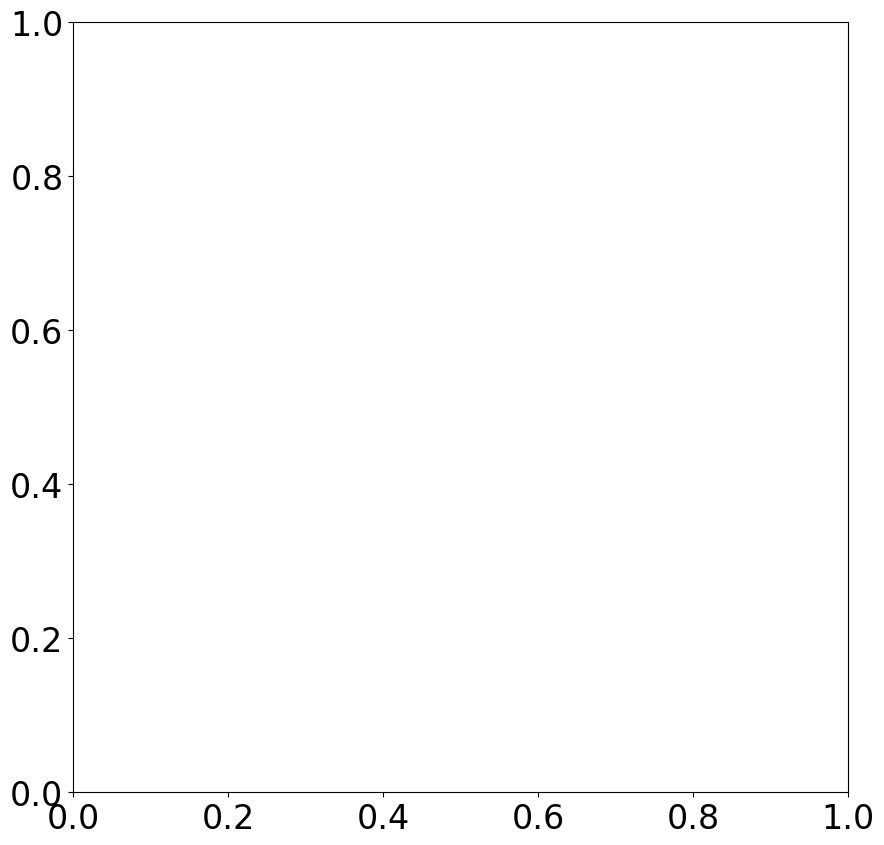

In [416]:
# Run everything.
def main() -> None:
    selected = (
        [name.strip() for name in ARGS["only"].split(",") if name.strip()]
        if ARGS["only"]
        else list(PLOTS)
    )
    ctx = PlotContext()
    if _bypass == 0:
        try:
            for name in selected:
                try:
                    with redirect_stdout(io.StringIO()):
                        path = PLOTS[name](ctx, ARGS["output_dir"])
                except Exception as exc:
                    print(f"{name}: ERROR: {exc}")
                    print(traceback.format_exc())
                else:
                    print(f"{name}: {path}")
        finally:
            ctx.close()
    else:
        sensitivity_test_plot_column_process_scan(ctx, OUTPUT_DIR, (0, 5000), PERIOD, RAW_PATH.stem)
        ctx.close()
    

if __name__ == "__main__":
    main()


This is if you want to see the data quickly.

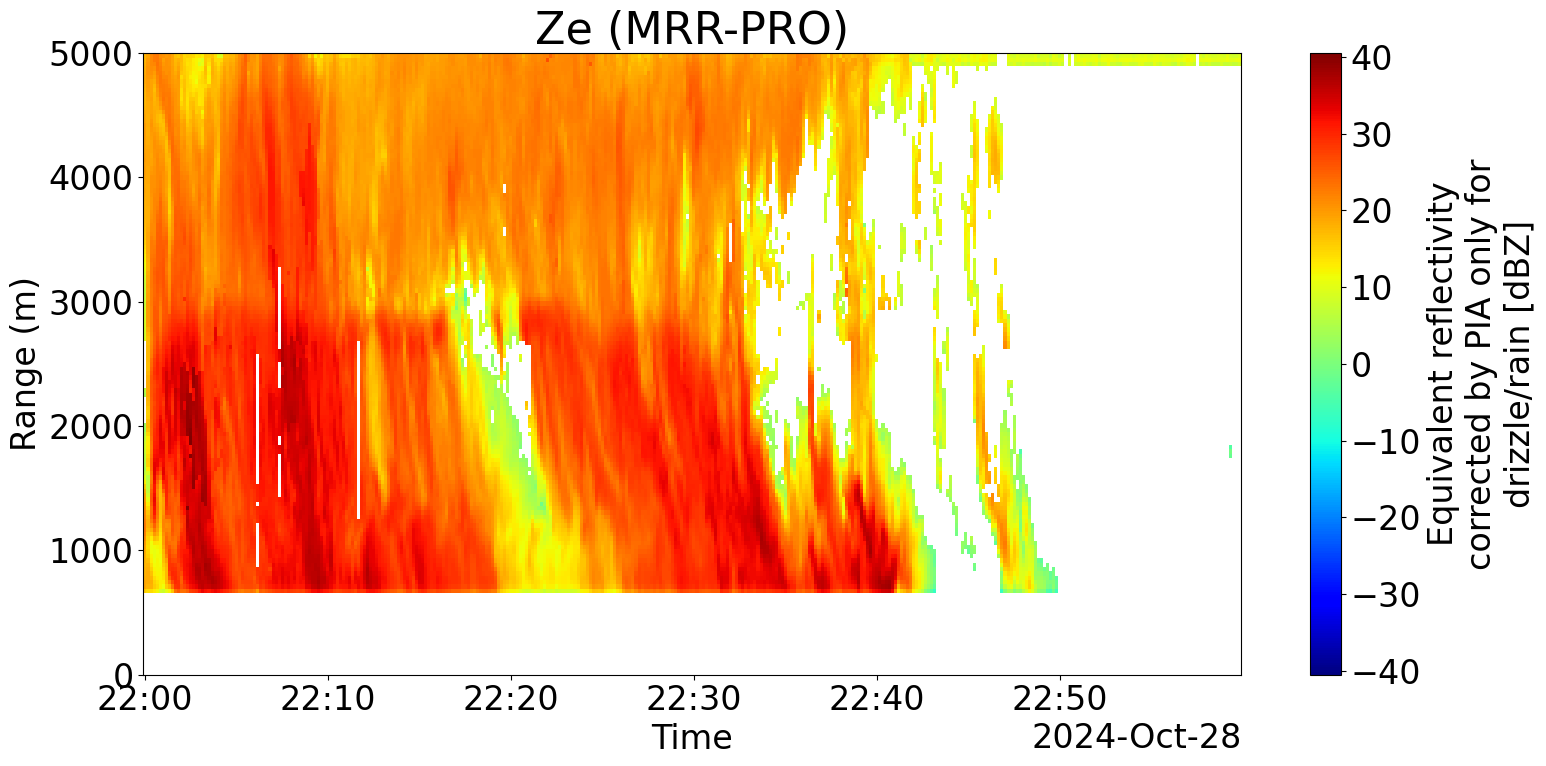

In [417]:
fig, ax = mrr.quicklook()
ax.plot()
ax.set_ylim(0, 5000)
plt.show()  

I want to see the max and minimum of the reflectivity.

<xarray.DataArray 'Za' (time: 360, range: 128)> Size: 184kB
[46080 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 3kB 2024-10-28T22:00:00.007906048 ... 20...
  * range      (range) float32 512B 640.0 675.0 710.0 ... 5.05e+03 5.085e+03
    elevation  (time) float32 1kB ...
    azimuth    (time) float32 1kB ...
Attributes:
    standard_name:     log_attenuated_reflectivity
    long_name:         
    units:             dBZ
    field_folds:       false
    fold_limit_lower:  0.0
    fold_limit_upper:  0.0
    thresholding_xml:  
    legend_xml:        
    is_discreet:       false
Max Za: 36.40883255004883, at {'time': np.datetime64('2024-10-28T22:03:10.007910912'), 'range': np.float32(1025.0)} 


c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


Max Ze: 44.73239345300291, at {'time': np.datetime64('2024-10-28T22:02:50.007906048'), 'range': np.float32(1235.0)} 


c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


Max Zea: 38.24483380799794, at {'time': np.datetime64('2024-10-28T22:40:40.007911936'), 'range': np.float32(710.0)} 


c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


Max Z: 44.2738165970954, at {'time': np.datetime64('2024-10-28T22:02:50.007906048'), 'range': np.float32(1235.0)} 


c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Projects\mrrpropy\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


Min Za: -13.612576484680176, at {'time': np.datetime64('2024-10-28T22:48:50.007917824'), 'range': np.float32(955.0)}
Min Ze: -13.381670164351394, at {'time': np.datetime64('2024-10-28T22:48:50.007917824'), 'range': np.float32(955.0)}
Min Zea: -13.38191623353121, at {'time': np.datetime64('2024-10-28T22:48:50.007917824'), 'range': np.float32(955.0)}
Min Z: -13.612330690543553, at {'time': np.datetime64('2024-10-28T22:48:50.007917824'), 'range': np.float32(955.0)}


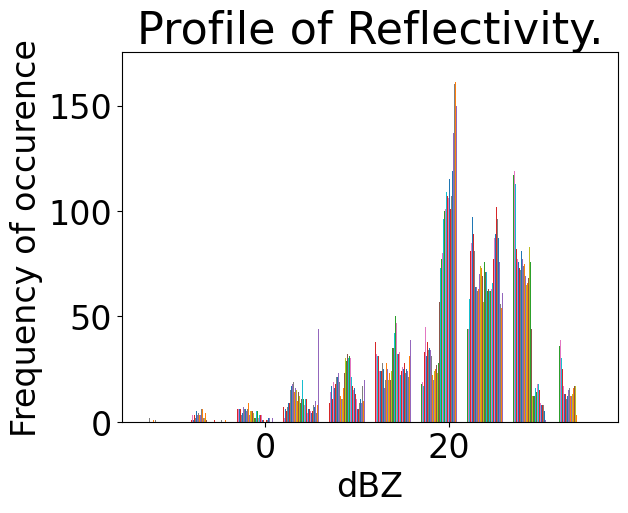

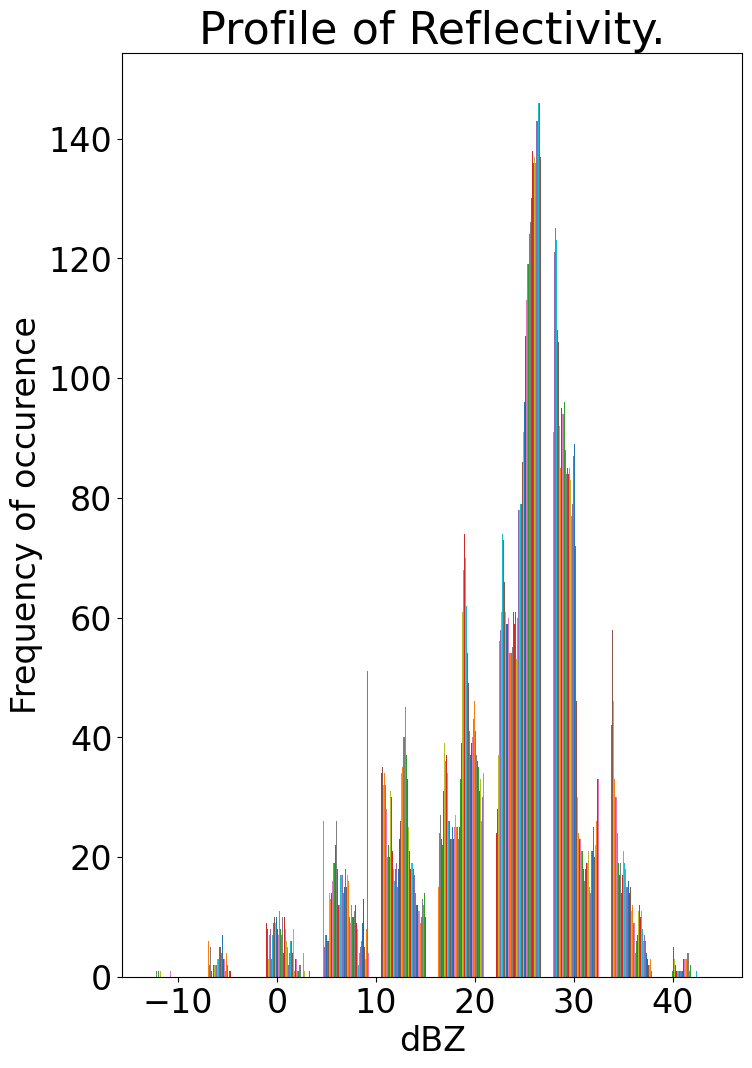

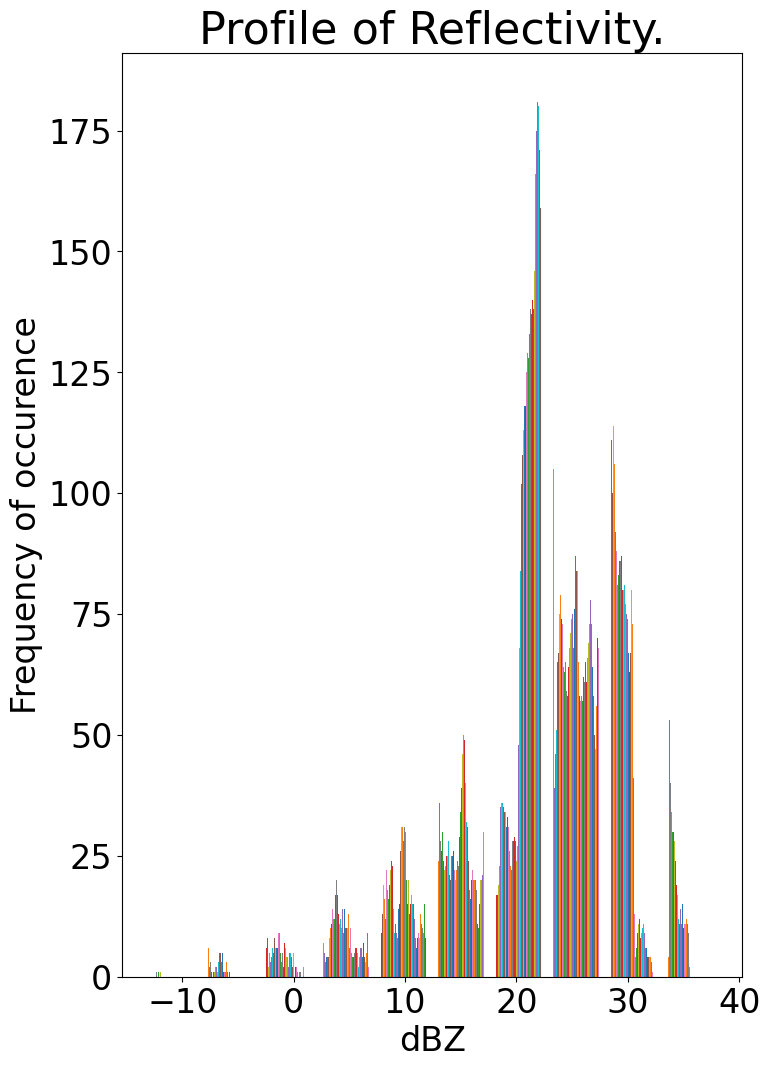

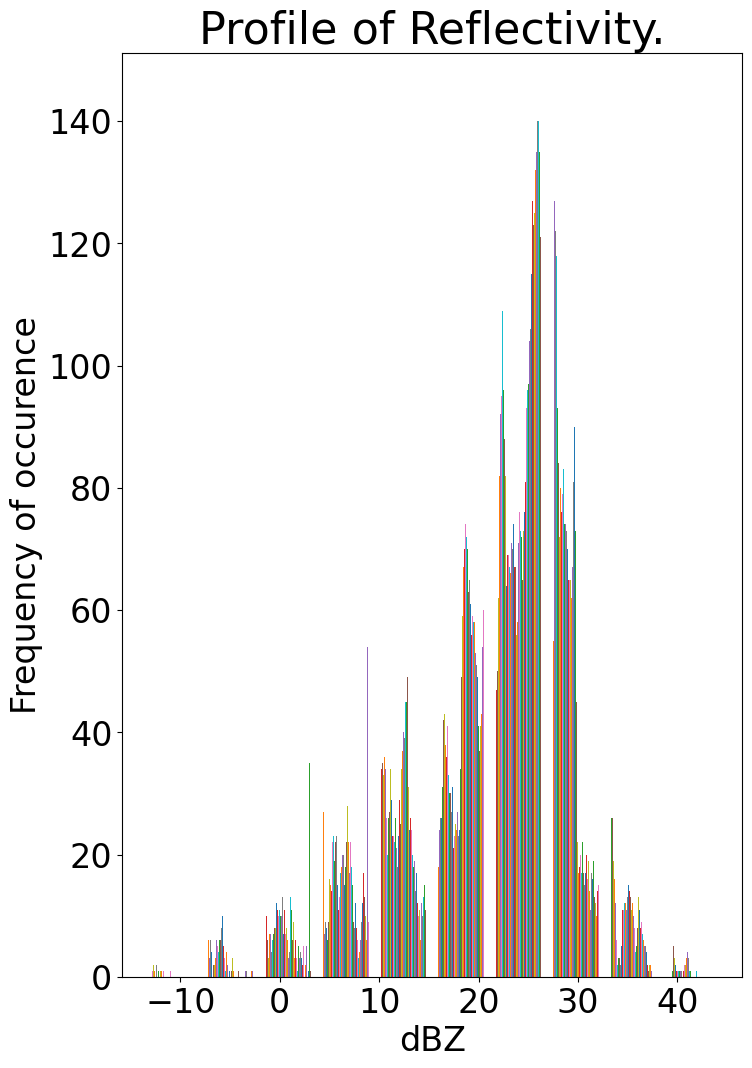

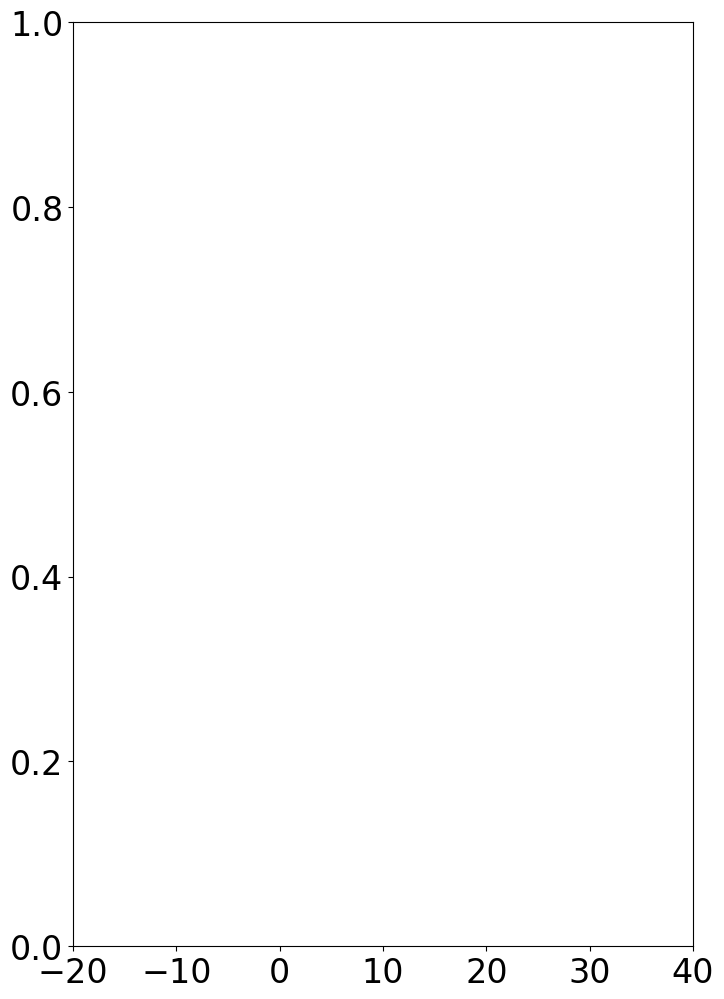

In [418]:
# Better max viewer
data = [mrr.ds["Za"], mrr.ds["Ze"], mrr.ds["Zea"], mrr.ds["Z"]]
print(mrr.ds["Za"])


# loop through all and add max
for i in data:
    _max = i.max().item()
    sel=i.where(i==_max, drop=True)
    coords = {dim: sel.coords[dim].values[0] for dim in sel.dims if dim in sel.coords}
    print(f"Max {i.name}: {_max}, at {coords} ")
    plt.hist(i)
    plt.ylabel("Frequency of occurence")
    plt.xlabel("dBZ")
    plt.title("Profile of Reflectivity.")
    plt.figure(figsize=(8,12))
    plt.xticks(np.arange(-20,50,10))
    plt.grid
    

for i in data: 
    _min = i.min().item()
    sel = i.where(i==_min, drop=True)
    coords = {dim:sel.coords[dim].values[0] for dim in sel.dims if dim in sel.coords}
    print(f"Min {i.name}: {_min}, at {coords}")

Quick 2d hist.

C:\Users\kelle\AppData\Local\Temp\ipykernel_38520\3860563681.py:40: RuntimeWarning: divide by zero encountered in log10
  H_log = np.where(H > 0, np.log10(H), np.nan)


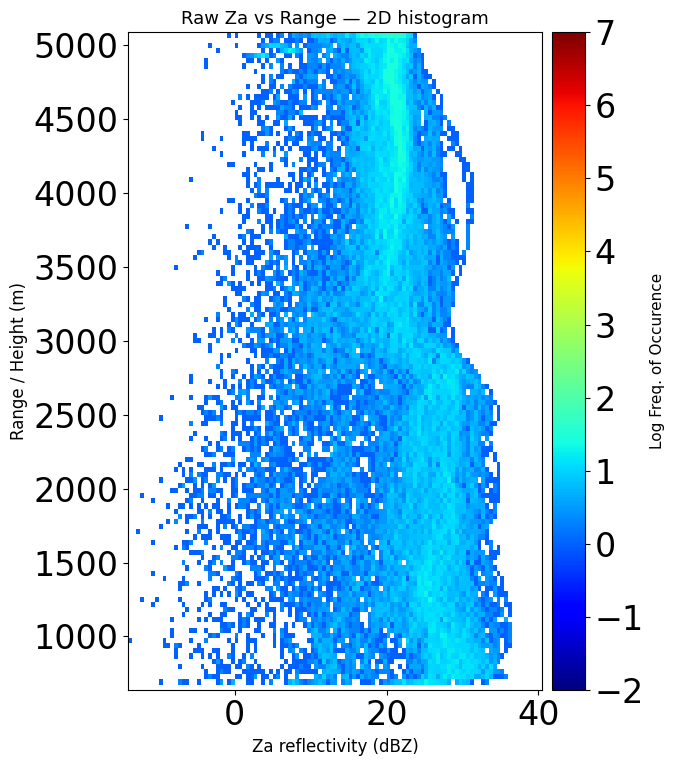

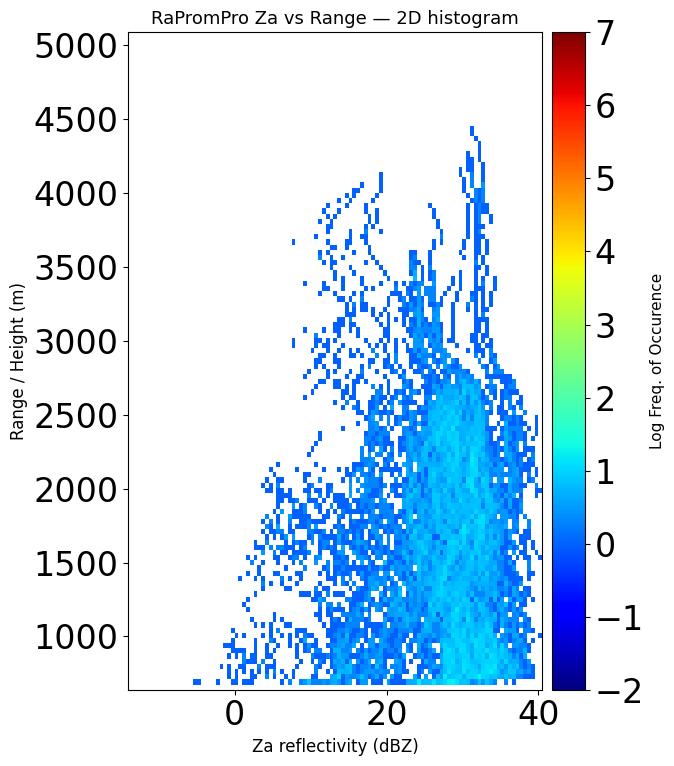

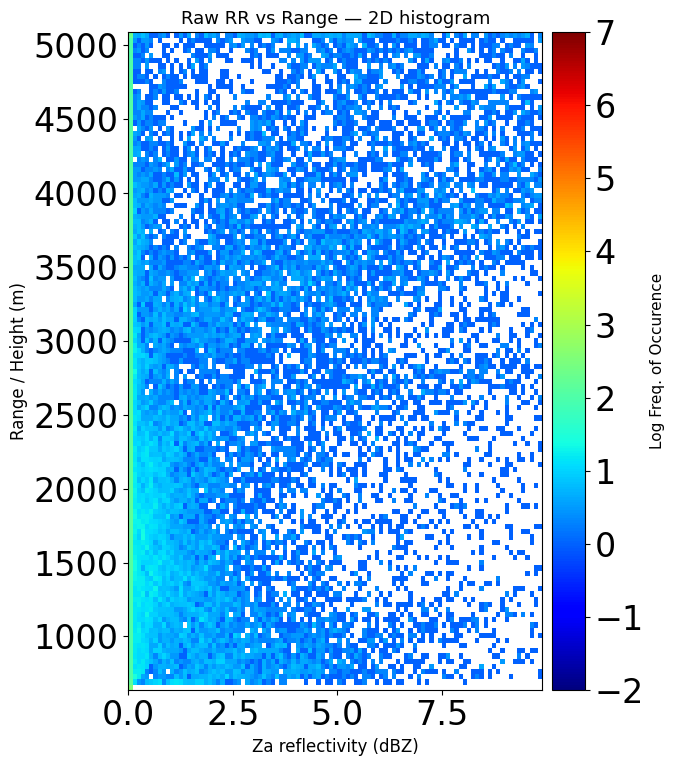

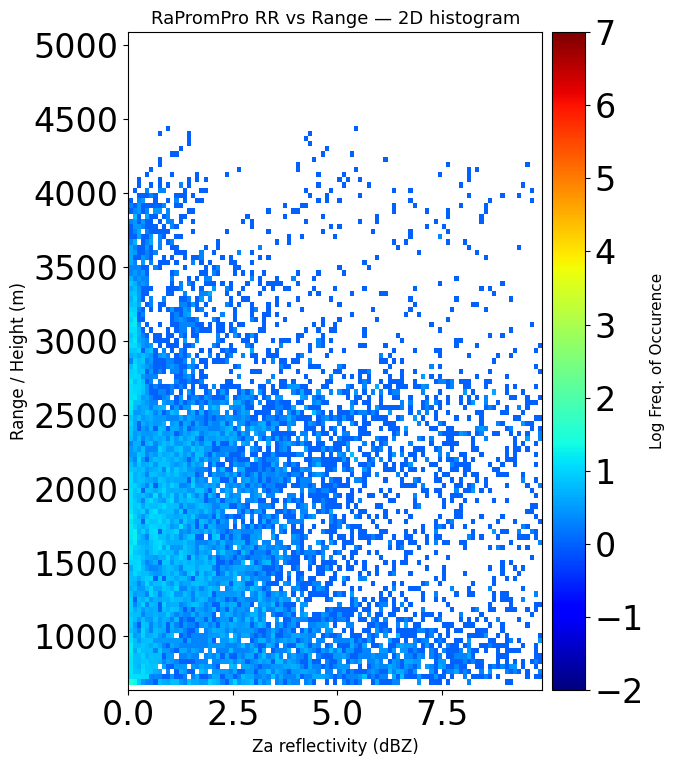

(<Figure size 700x800 with 2 Axes>,
 <Axes: title={'center': 'RaPromPro RR vs Range — 2D histogram'}, xlabel='Za reflectivity (dBZ)', ylabel='Range / Height (m)'>)

In [419]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr

def plot_za_range_histogram(ds_za, za_bins=None, range_bins=None, cmap='jet', fig_title=None):
    """
    2D histogram of Za (reflectivity) vs range, colored by log10(count).
    
    Parameters
    ----------
    ds_za : xr.DataArray
        DataArray with dims (time, range), coords 'range' in meters.
    za_bins : array-like, optional
        Bin edges for Za (dBZ). Defaults to -5 to 40 in 1 dBZ steps.
    range_bins : array-like, optional
        Bin edges for range (m). Defaults to full extent in 50 m steps.
    """
    za_vals = ds_za.values.ravel()          # flatten time × range
    range_coord = ds_za.coords['range'].values
    range_vals = np.tile(range_coord, ds_za.sizes['time'])

    # drop NaNs together
    mask = np.isfinite(za_vals) & np.isfinite(range_vals)
    za_vals = za_vals[mask]
    range_vals = range_vals[mask]

    if za_bins is None:
        za_bins = np.arange(-5, 41, 1)          # dBZ
    if range_bins is None:
        r0, r1 = range_coord.min(), range_coord.max()
        range_bins = np.arange(r0, r1 + 50, 50)  # 50 m steps

    H, xedges, yedges = np.histogram2d(
        za_vals, range_vals,
        bins=[za_bins, range_bins]
    )

    # log10 of count; mask zeros
    H_log = np.where(H > 0, np.log10(H), np.nan)

    fig, ax = plt.subplots(figsize=(7, 8))

    pcm = ax.pcolormesh(
        xedges, yedges, H_log.T,   # transpose: rows=range, cols=Za
        cmap=cmap,
        vmin=-2, vmax=7,
        shading='flat'
    )

    cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label('Log Freq. of Occurence', fontsize=11)
    cbar.set_ticks([-2, -1, 0, 1, 2, 3, 4, 5, 6, 7])

    ax.set_xlabel('Za reflectivity (dBZ)', fontsize=12)
    ax.set_ylabel('Range / Height (m)', fontsize=12)
    ax.set_xlim(za_bins[0], za_bins[-1])
    ax.set_ylim(range_bins[0], range_bins[-1])

    if fig_title:
        ax.set_title(fig_title, fontsize=13)

    plt.tight_layout()
    plt.show()
    return fig, ax


# --- usage ---
plot_za_range_histogram(
    mrr.ds['Za'],
    za_bins=np.arange(-14, 41, 0.5),   # finer Za bins
    range_bins=np.arange(640, 5100, 35),
    cmap='jet',
    fig_title='Raw Za vs Range — 2D histogram'
)

plot_za_range_histogram(
    mrr.raprompro['Za'],
    za_bins=np.arange(-14, 41, 0.5),   # finer Za bins
    range_bins=np.arange(640, 5100, 35),
    cmap='jet',
    fig_title='RaPromPro Za vs Range — 2D histogram'
)

plot_za_range_histogram(
    mrr.ds["RR"],
    za_bins=np.arange(0, 10, 0.1),   # finer Za bins
    range_bins=np.arange(640, 5100, 35),
    cmap='jet',
    fig_title='Raw RR vs Range — 2D histogram'
)

plot_za_range_histogram(
    mrr.raprompro["RR"],
    za_bins=np.arange(0, 10, 0.1),   # finer Za bins
    range_bins=np.arange(640, 5100, 35),
    cmap='jet',
    fig_title='RaPromPro RR vs Range — 2D histogram'
)